In [2]:
# pandas is used for handling datasets
import pandas as pd

# train_test_split helps divide data into training and testing
from sklearn.model_selection import train_test_split

# LinearRegression is the ML algorithm
from sklearn.linear_model import LinearRegression

# mean_absolute_error checks prediction accuracy
from sklearn.metrics import mean_absolute_error

In [3]:
data = pd.read_csv("train.csv")

print(data.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [4]:
# Selecting useful columns for prediction

X = data[['GrLivArea', 'BedroomAbvGr', 'FullBath']]

In [5]:
# Target column we want to predict

y = data['SalePrice']

In [6]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,      # Input features
    y,      # Target values
    test_size=0.2,   # 20% for testing
    random_state=42  # Fixed random values
)

In [7]:
# Create Linear Regression model

model = LinearRegression()

In [8]:
# Train model using training data

model.fit(X_train, y_train)

LinearRegression()

In [9]:
# Predict prices using testing data

predictions = model.predict(X_test)

# Show first 5 predictions
print(predictions[:5])

[113410.67255298 305081.87775899 135904.78562983 205424.67564124
 227502.68349004]


In [10]:
# Calculate prediction error

mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 35788.061292436294


In [13]:
# Example house:
# 2000 square feet
# 3 bedrooms
# 2 bathrooms

example_house = pd.DataFrame(
    [[2000, 3, 2]],
    columns=['GrLivArea', 'BedroomAbvGr', 'FullBath']
)

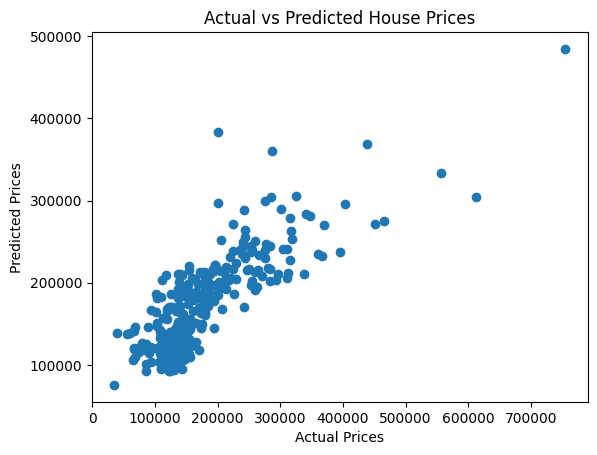

In [12]:
import matplotlib.pyplot as plt

# Create graph
plt.scatter(y_test, predictions)

# Labels
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

# Graph title
plt.title("Actual vs Predicted House Prices")

# Show graph
plt.show()